In [138]:
import pandas as pd

#Load dataset
df=pd.read_csv('../data/spotify.csv',na_values=['',' ','-'],encoding='latin')

display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            953 non-null    str    
 1   released_year         953 non-null    int64  
 2   in_spotify_playlists  953 non-null    int64  
 3   in_spotify_charts     951 non-null    float64
 4   streams               953 non-null    int64  
 5   in_apple_playlists    953 non-null    int64  
 6   in_apple_charts       951 non-null    float64
 7   bpm                   953 non-null    int64  
 8   mode                  953 non-null    str    
 9   energy                953 non-null    int64  
 10  instrumentalness      953 non-null    int64  
 11  liveness              953 non-null    int64  
 12  speechiness           953 non-null    int64  
dtypes: float64(2), int64(9), str(2)
memory usage: 96.9 KB


None

In [139]:
# Remove track name column because it is not useful for numerical clustering analysis

df.drop(columns=['track_name','instrumentalness'],inplace=True)

In [140]:
df=df[df['speechiness']<=60]
# Remove rows with unrealistic speechiness values

In [141]:
#Replace missing values with median
median_spot=df['in_spotify_charts'].median()
median_ap=df['in_apple_charts'].median()

df['in_apple_charts']=df['in_apple_charts'].fillna(median_ap)
df['in_spotify_charts']=df['in_spotify_charts'].fillna(median_spot)

In [142]:
# The values 0 in these columns mean that the song is not present
# on the chart. Since smaller values represent better positions,
# keeping 0 would incorrectly make these songs look like the best ranked ones.
#
# Replacing 0 with the median value would also not be realistic because
# it would represent an average chart position.
#
# Therefore, 0 values are replaced with the maximum value in each column,
# representing the lowest chart position.

df.loc[df["in_apple_charts"] == 0,"in_apple_charts"] = df["in_apple_charts"].max()
df.loc[df["in_spotify_charts"] == 0,"in_spotify_charts"] = df["in_spotify_charts"].max()

# Check the updated dataset
df.describe()

,released_year,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,bpm,energy,liveness,speechiness
count,952.000000,952.000000,952.000000,9.520000e+02,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000
mean,2018.233193,5205.304622,74.398109,5.146578e+08,67.876050,80.603992,122.555672,64.297269,18.211134,10.074580
std,11.120988,7900.140377,64.622987,5.666776e+08,86.464421,81.631508,28.068585,16.549733,13.718308,9.762894
min,1930.000000,31.000000,1.000000,2.762000e+03,0.000000,1.000000,65.000000,9.000000,3.000000,2.000000
25%,2020.000000,878.750000,11.000000,1.420017e+08,13.000000,16.000000,99.750000,53.000000,10.000000,4.000000
50%,2022.000000,2225.000000,42.000000,2.912715e+08,34.000000,58.500000,121.000000,66.000000,12.000000,6.000000
75%,2022.000000,5573.750000,147.000000,6.738690e+08,88.000000,108.250000,140.250000,77.000000,24.000000,11.000000
max,2023.000000,52898.000000,147.000000,3.703895e+09,672.000000,275.000000,206.000000,97.000000,97.000000,59.000000


In [143]:
# Convert categorical variable "mode" into numerical values
# Major = 0
# Minor = 1

df['mode']=df['mode'].map({'Major':0,'Minor':1})
df.info()

<class 'pandas.DataFrame'>
Index: 952 entries, 0 to 952
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   released_year         952 non-null    int64  
 1   in_spotify_playlists  952 non-null    int64  
 2   in_spotify_charts     952 non-null    float64
 3   streams               952 non-null    int64  
 4   in_apple_playlists    952 non-null    int64  
 5   in_apple_charts       952 non-null    float64
 6   bpm                   952 non-null    int64  
 7   mode                  952 non-null    int64  
 8   energy                952 non-null    int64  
 9   liveness              952 non-null    int64  
 10  speechiness           952 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 89.2 KB


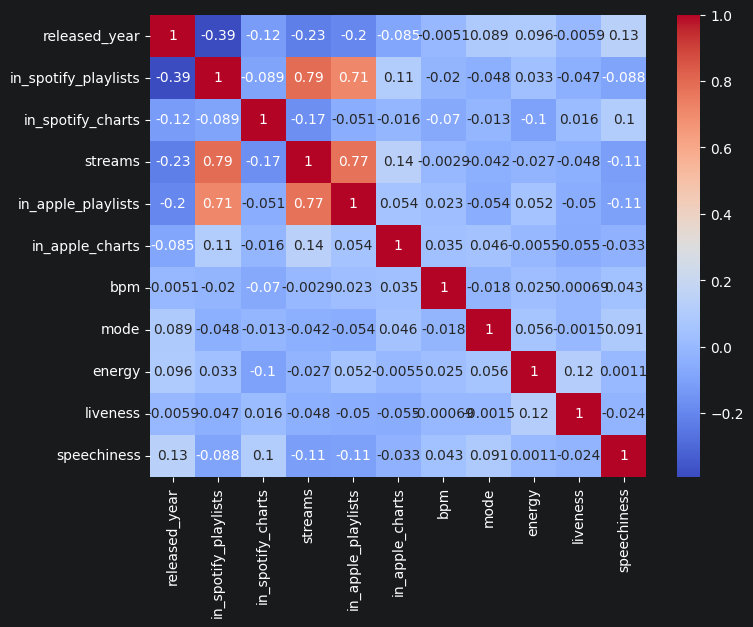

In [144]:
# Display correlation matrix between numerical features
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize=(8, 6))
sb.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [145]:
df.drop(columns=['streams','in_apple_playlists'],inplace=True)
# Removed highly correlated features
# These variables provide similar information and can negatively
# affect clustering results

In [146]:
# Function for displaying boxplots used to identify possible outliers in features
# Outliers are treated because they can make the clustering results less accurate by affecting the distance between data points.
def draw_boxplot(data):
    plt.figure(figsize=(8,6))
    plt.boxplot(data)
    plt.show()

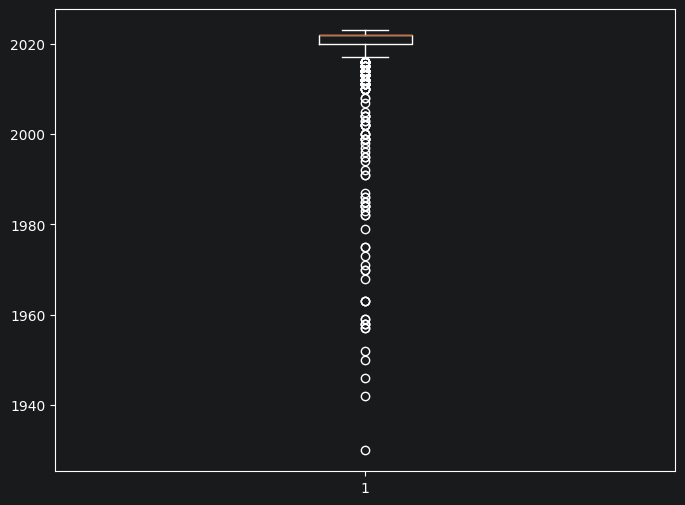

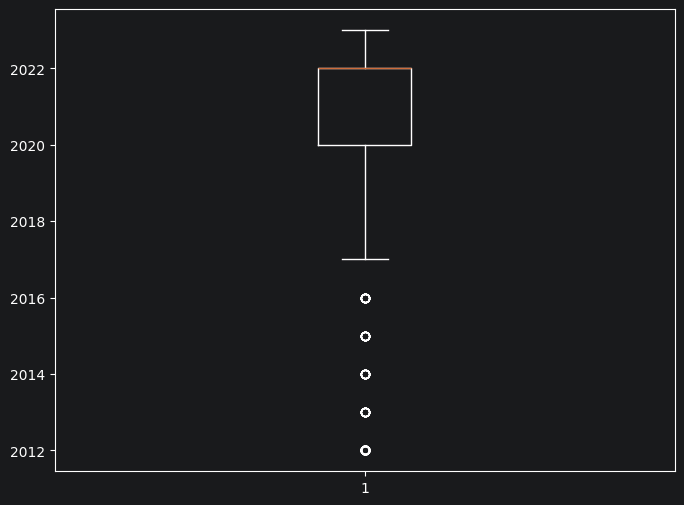

In [147]:
draw_boxplot(df['released_year'])
# Apply Winsorization to reduce the influence of extreme values
from scipy.stats.mstats import winsorize
wins_data=winsorize(df['released_year'],limits=[0.1,0.0])
draw_boxplot(wins_data)
# The feature contains more than 10% outliers.
# Since a large number of extreme values can negatively affect the clustering process, this variable is removed from the dataset.
df.drop(columns=['released_year'],inplace=True
        )

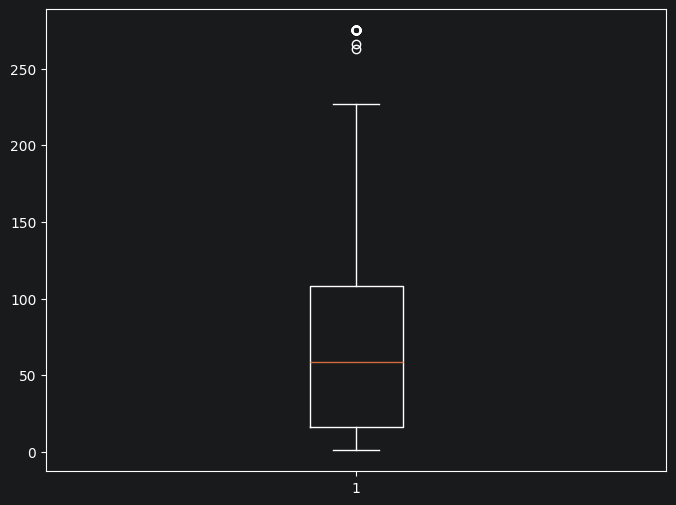

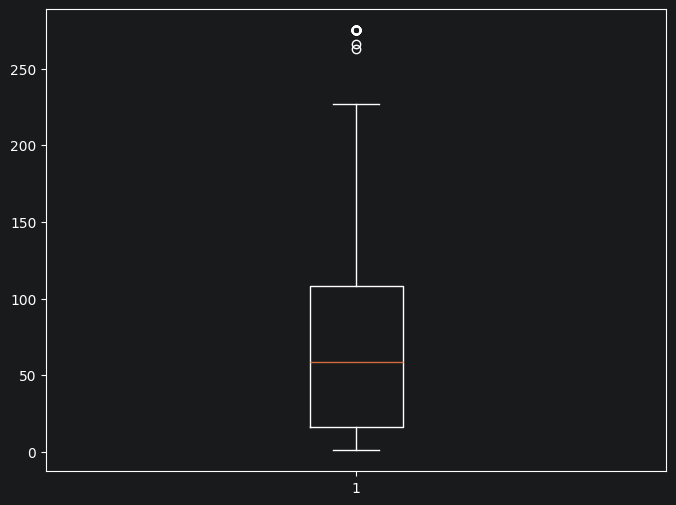

In [148]:
draw_boxplot(df['in_apple_charts'])
wins_data=winsorize(df['in_apple_charts'],limits=[0.0,0.1])
draw_boxplot(wins_data)

df.drop(columns=['in_apple_charts'],inplace=True)



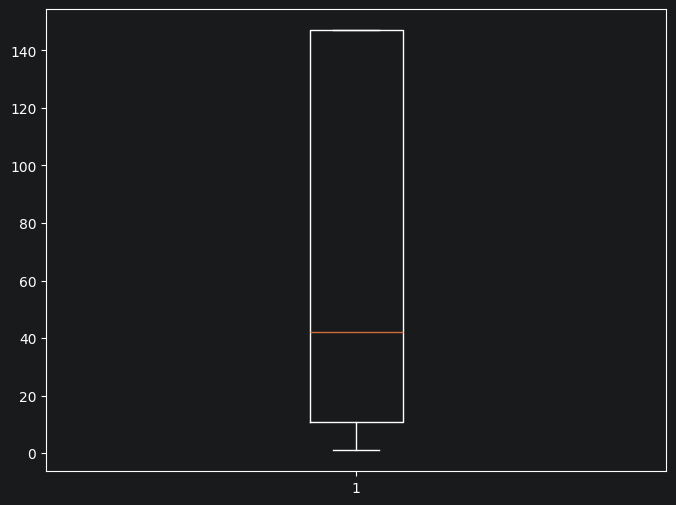

In [149]:
draw_boxplot(df['in_spotify_charts'])

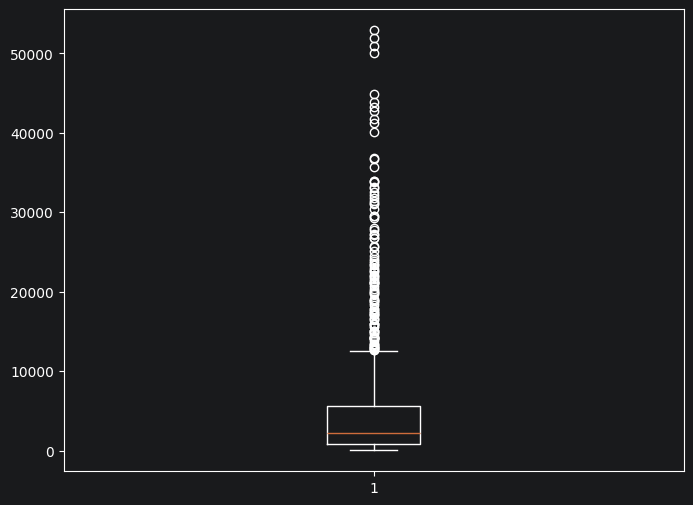

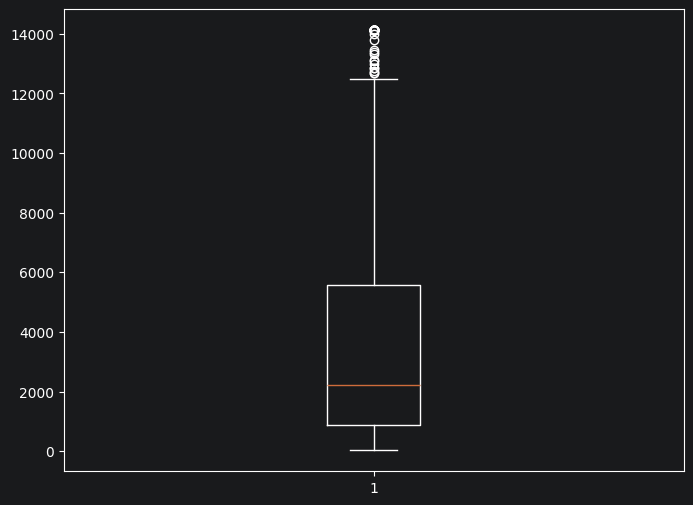

In [150]:
draw_boxplot(df['in_spotify_playlists'])

wins_data1=winsorize(df['in_spotify_playlists'],limits=[0.0,0.1])
draw_boxplot(wins_data1)

df.drop(columns=['in_spotify_playlists'],inplace=True)

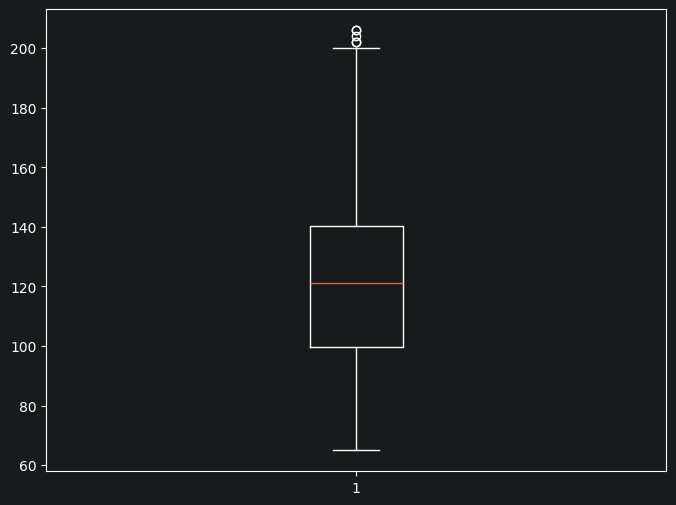

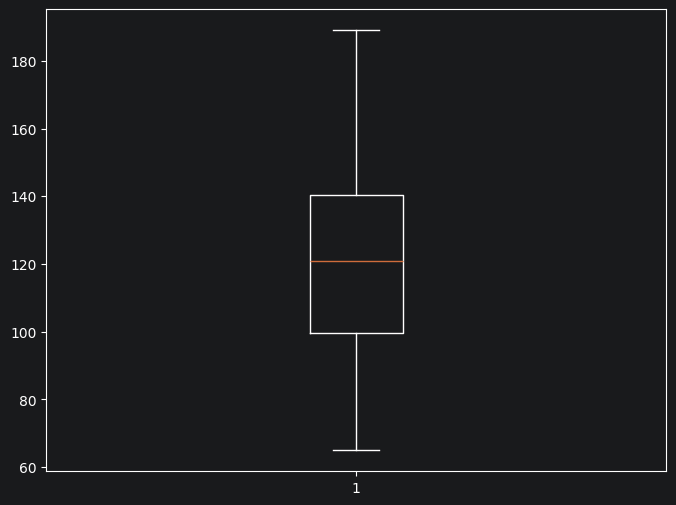

In [151]:
draw_boxplot(df['bpm'])
wins_data=winsorize(df['bpm'],limits=[0.0,0.01])
draw_boxplot(wins_data)

df['bpm']=wins_data

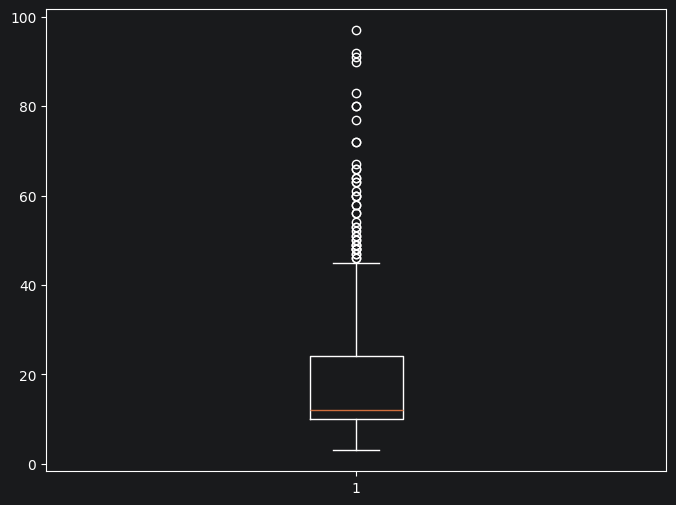

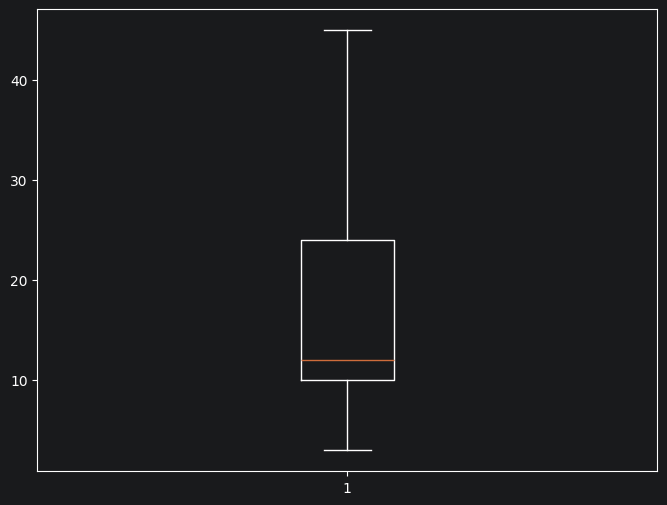

In [152]:
draw_boxplot(df['liveness'])
wins_data1=winsorize(df['liveness'],limits=[0.0,0.05])
draw_boxplot(wins_data1)

df['liveness']=wins_data1

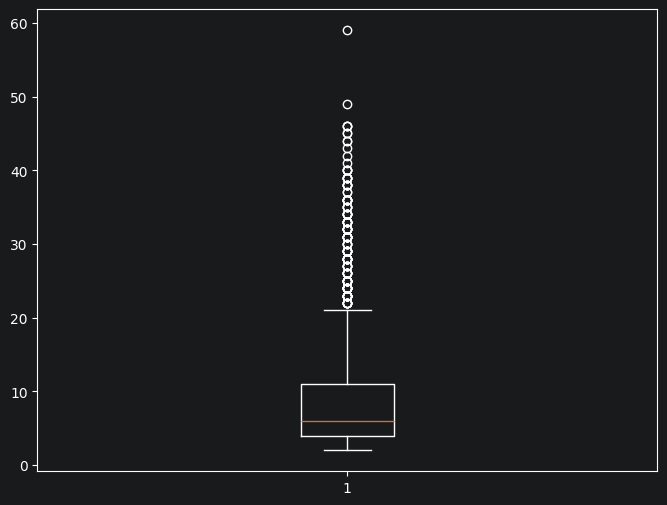

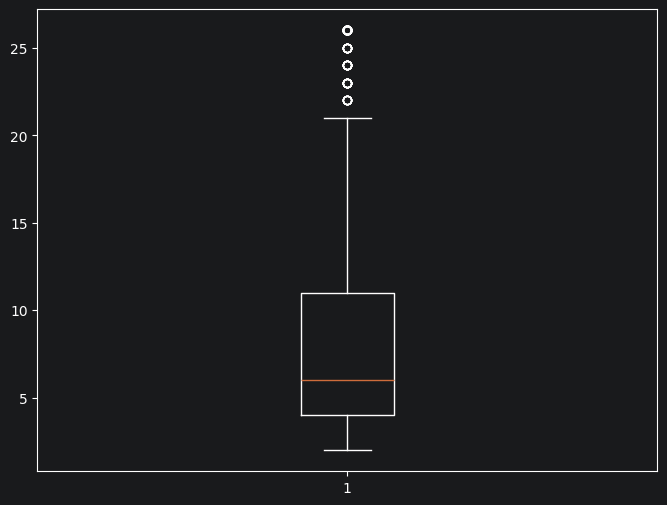

In [153]:
draw_boxplot(df['speechiness'])

wins_data1=winsorize(df['speechiness'],limits=[0.0,0.1])
draw_boxplot(wins_data1)

df.drop(columns='speechiness',inplace=True)

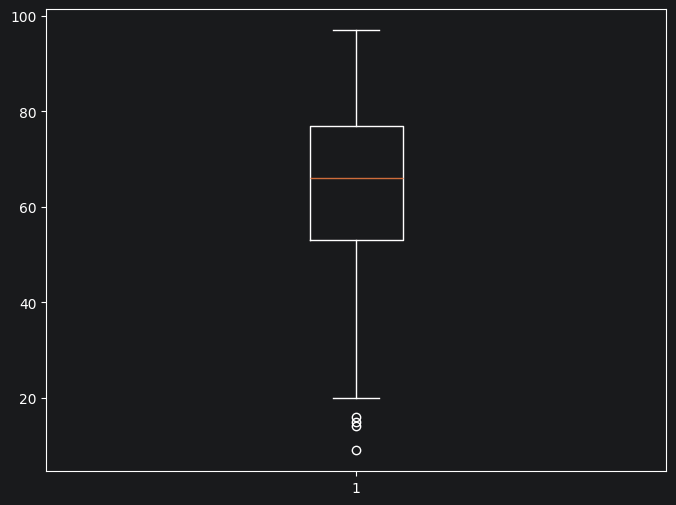

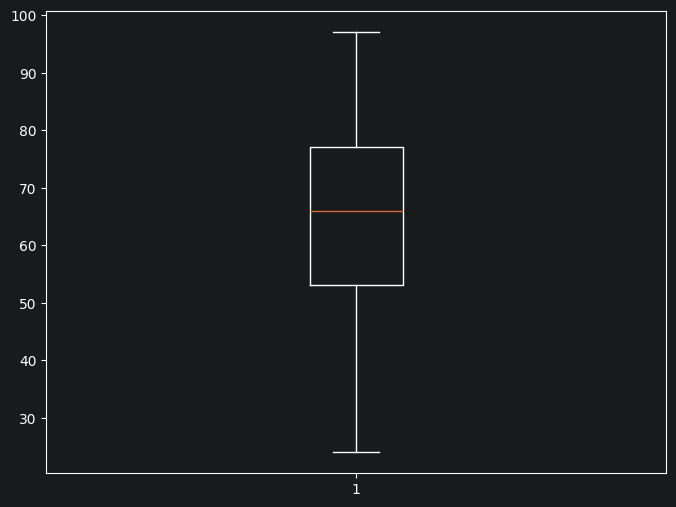

In [154]:
draw_boxplot(df['energy'])
wins_data1=winsorize(df['energy'],limits=[0.01,0.0])
draw_boxplot(wins_data1)

df['energy']=wins_data1


In [155]:
df.describe()

C:\Users\Joska Stojanovic\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\Joska Stojanovic\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\Joska Stojanovic\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,in_spotify_charts,bpm,mode,energy,liveness
count,952.000000,952.000000,952.000000,952.000000,952.000000
mean,74.398109,122.445378,0.422269,64.359244,17.460084
std,64.622987,27.779270,0.494181,16.380695,11.231925
min,1.000000,65.000000,0.000000,24.000000,3.000000
25%,11.000000,99.750000,0.000000,53.000000,10.000000
50%,42.000000,121.000000,0.000000,66.000000,12.000000
75%,147.000000,140.250000,1.000000,77.000000,24.000000
max,147.000000,189.000000,1.000000,97.000000,45.000000


In [156]:
import sklearn.cluster as cluster
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage,dendrogram

# Normalize features before clustering
# Scaling is required because clustering algorithms are distance-based
scaler=MinMaxScaler()

df_scaled=pd.DataFrame(scaler.fit_transform(df),
                       index=df.index,
                       columns=df.columns)

display(df_scaled.describe())

,in_spotify_charts,bpm,mode,energy,liveness
count,952.000000,952.000000,952.000000,952.000000,952.000000
mean,0.502727,0.463269,0.422269,0.552866,0.344288
std,0.442623,0.224026,0.494181,0.224393,0.267427
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.068493,0.280242,0.000000,0.397260,0.166667
50%,0.280822,0.451613,0.000000,0.575342,0.214286
75%,1.000000,0.606855,1.000000,0.726027,0.500000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [157]:
df_scaled.head()

,in_spotify_charts,bpm,mode,energy,liveness
0,1.000000,0.483871,0.0,0.808219,0.119048
1,0.321918,0.217742,0.0,0.684932,0.166667
2,0.767123,0.588710,0.0,0.397260,0.666667
3,0.013699,0.846774,0.0,0.657534,0.190476
4,0.335616,0.637097,1.0,0.767123,0.190476


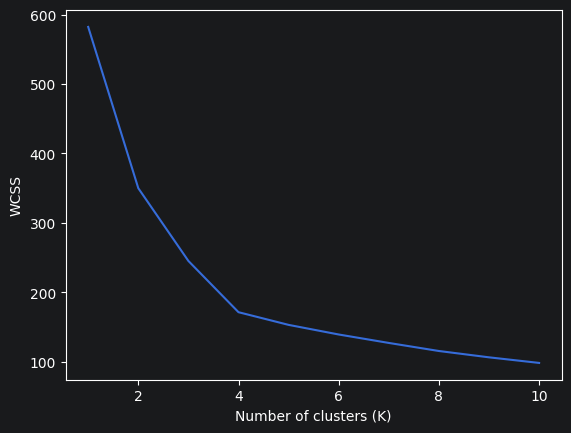

In [158]:
# Elbow Method
# Calculate WCSS for different numbers of clusters
# to determine optimal cluster number
wcss = []

# Probamo od 1 do 10 klastera
for i in range(1, 11):
    kmeans = cluster.KMeans(n_clusters=i, init='k-means++', max_iter=100, n_init=1000, random_state=0).fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.show()


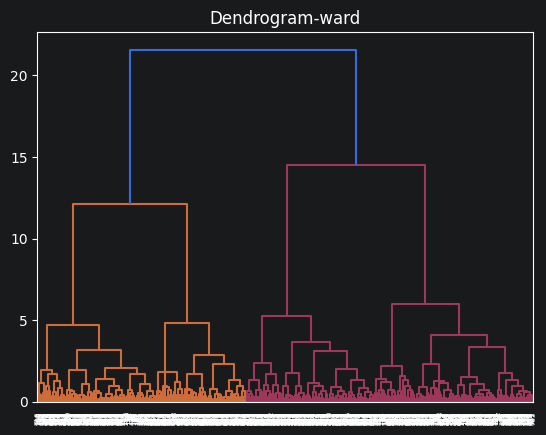

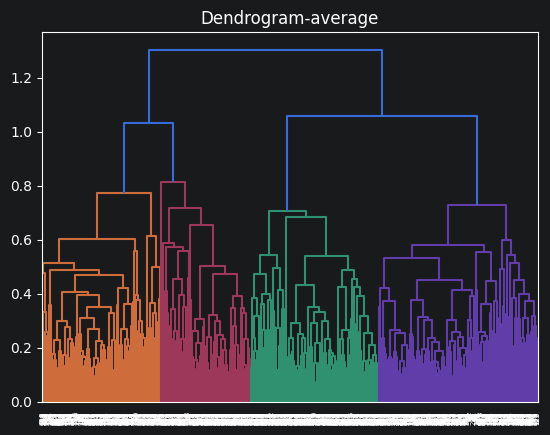

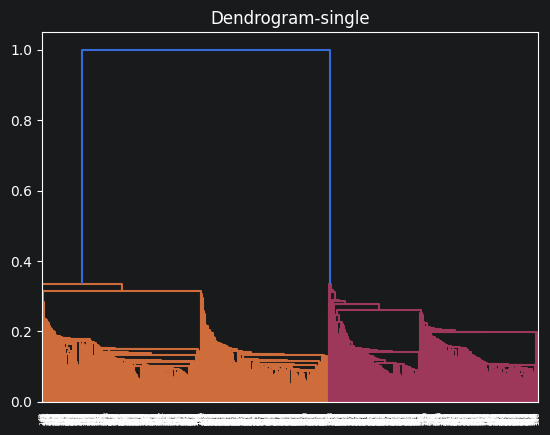

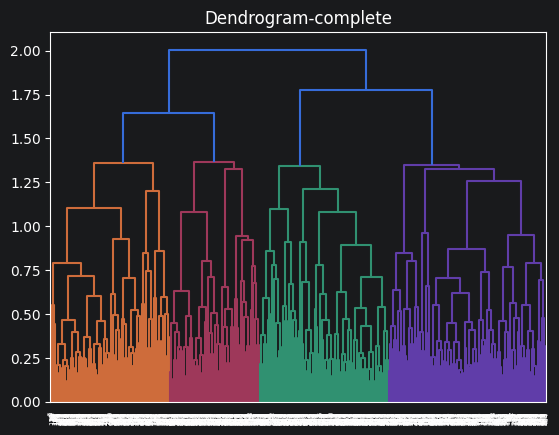

In [159]:
dendrogram(linkage(df_scaled,method='ward',metric='euclidean'))
plt.title('Dendrogram-ward')
plt.show()

dendrogram(linkage(df_scaled,method='average',metric='euclidean'))
plt.title('Dendrogram-average')
plt.show()

dendrogram(linkage(df_scaled,method='single',metric='euclidean'))
plt.title('Dendrogram-single')
plt.show()

dendrogram(linkage(df_scaled,method='complete',metric='euclidean'))
plt.title('Dendrogram-complete')
plt.show()

In [160]:
#The Elbow Method is used to determine the optimal number of clusters.
#The elbow point represents the moment when adding more clusters
#does not significantly improve the clustering quality.
#In this case, possible elbow points appear at 2 and 4
# 4 clusters were selected because the decrease in WCSS becomes smaller after this point
#Both K-Means and Agglomerative Clustering will be trained using the same number of clusters. Their performance will be compared using Silhouette Score.

In [161]:
from sklearn.cluster import AgglomerativeClustering,KMeans
from sklearn.metrics import silhouette_score

# Define number of clusters selected from Elbow Method
n_clusters = 4

#Apply K-Means clustering
kmeans = KMeans(
    n_clusters=n_clusters,
    init='k-means++',
    n_init=100,
    max_iter=300,
    random_state=42
)
kmeans_labels = kmeans.fit_predict(df_scaled)
# Calculate K-Means Silhouette Score
kmeans_score = silhouette_score(df_scaled,kmeans_labels)

# Apply Agglomerative Clustering
agglomerative = AgglomerativeClustering(n_clusters=n_clusters,linkage='ward')
agg_labels = agglomerative.fit_predict(df_scaled)
# Calculate Agglomerative Silhouette Score
agg_score = silhouette_score(df_scaled,agg_labels)

# Compare algorithms
comparison = pd.DataFrame(
    {
        "Algorithm":["K-Means","Agglomerative Clustering"],
        "Silhouette Score":[kmeans_score,agg_score]
    }
)
display(comparison)
# The algorithm with the higher Silhouette Score provides better
# separated and more compact clusters for this dataset.
df_scaled['kmeans_cluster'] = kmeans_labels
df_scaled['agglomerative_cluster'] = agg_labels


,Algorithm,Silhouette Score
0,K-Means,0.468775
1,Agglomerative Clustering,0.468413


In [165]:
df_scaled.head()

,in_spotify_charts,bpm,mode,energy,liveness,kmeans_cluster,agglomerative_cluster
0,1.000000,0.483871,0.0,0.808219,0.119048,1,2
1,0.321918,0.217742,0.0,0.684932,0.166667,0,0
2,0.767123,0.588710,0.0,0.397260,0.666667,1,2
3,0.013699,0.846774,0.0,0.657534,0.190476,0,0
4,0.335616,0.637097,1.0,0.767123,0.190476,2,3


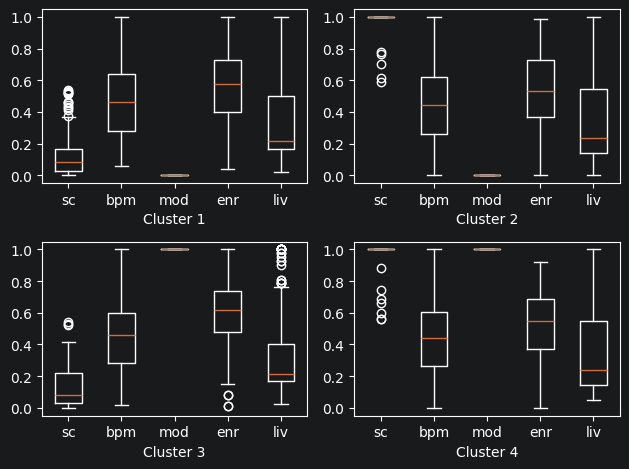

Cluster 1, N =  305
Cluster 2, N =  245
Cluster 3, N =  229
Cluster 4, N =  173


In [163]:
# Draw boxplots for the four K-Means clusters to compare their characteristics
fig, ax = plt.subplots(2, 2)

# Cluster 1
ax[0,0].boxplot(df_scaled[df_scaled["kmeans_cluster"] == 0].drop(columns=['kmeans_cluster', 'agglomerative_cluster']),
                tick_labels=("sc", "bpm", "mod", "enr", "liv"))
ax[0,0].set_xlabel("Cluster 1")


# Cluster 2
ax[0,1].boxplot(df_scaled[df_scaled["kmeans_cluster"] == 1].drop(columns=['kmeans_cluster', 'agglomerative_cluster']),
    tick_labels=("sc", "bpm", "mod", "enr", "liv"))
ax[0,1].set_xlabel("Cluster 2")


# Cluster 3
ax[1,0].boxplot(df_scaled[df_scaled["kmeans_cluster"] == 2].drop(columns=['kmeans_cluster', 'agglomerative_cluster']),
    tick_labels=("sc", "bpm", "mod", "enr", "liv"))
ax[1,0].set_xlabel("Cluster 3")


# Cluster 4
ax[1,1].boxplot(df_scaled[df_scaled["kmeans_cluster"] == 3].drop(columns=['kmeans_cluster', 'agglomerative_cluster']),
    tick_labels=("sc", "bpm", "mod", "enr", "liv"))
ax[1,1].set_xlabel("Cluster 4")

plt.tight_layout()
plt.show()

print('Cluster 1, N=',df[df['kmeans_cluster']==0].shape[0])
print('Cluster 2, N=',df[df['kmeans_cluster']==1].shape[0])
print('Cluster 3, N=',df[df['kmeans_cluster']==2].shape[0])
print('Cluster 4, N=',df[df['kmeans_cluster']==3].shape[0])


In [ ]:
# Interpretation

# 1.Cluster sizes
#The first cluster contains 305 songs, the second 245,
#the third 229 and the fourth 173 songs. All clusters have
#a significant number of observations.

# 2. Cluster centers
#Cluster 1 contains songs in Major mode that are well ranked
#on the Spotify top list, while cluster 2 contains songs in Major mode that are poorly ranked on the Spotify top list.
#In contrast, cluster 3 contains songs in Minor mode that are well ranked on the Spotify top list, while cluster 4 contains
#songs in Minor mode that are poorly ranked on the Spotify top list.

# 3. Dispersion from cluster centers
#Clusters 2 and 4 are relatively homogeneous with respect to
#the in_spotify_charts attribute because they mainly contain poorly ranked songs.

# Clusters 1 and 3 contain better-ranked songs with more variation
# in their Spotify chart positions, so the dispersion for this
# attribute is somewhat higher.

# Cluster 3 is more homogeneous than the other clusters with
# respect to the energy and liveness attributes.

# There are no major differences in homogeneity between the
# clusters for the remaining attributes.